In [2]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [3]:
import pandas as pd

primary_df = pd.read_csv('/content/drive/MyDrive/ColabNotebooks/SCMCourseWork/dataFiles/germany/scpi_germany.csv')

print("Информация о загруженном датафрейме:")
primary_df.info()
display(primary_df.head(5))
primary_df.tail()

Информация о загруженном датафрейме:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 748 entries, 0 to 747
Data columns (total 11 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   index      748 non-null    int64  
 1   country    748 non-null    object 
 2   year       748 non-null    int64  
 3   gdp        748 non-null    float64
 4   infrate    727 non-null    float64
 5   trade      646 non-null    float64
 6   schooling  151 non-null    float64
 7   invest60   17 non-null     float64
 8   invest70   17 non-null     float64
 9   invest80   17 non-null     float64
 10  industry   541 non-null    float64
dtypes: float64(8), int64(2), object(1)
memory usage: 64.4+ KB


,index,country,year,gdp,infrate,trade,schooling,invest60,invest70,invest80,industry
0,1,USA,1960,2.879,NaN,9.693181,43.799999,NaN,NaN,NaN,NaN
1,1,USA,1961,2.929,1.075182,9.444654,NaN,NaN,NaN,NaN,NaN
2,1,USA,1962,3.103,1.116071,9.429324,NaN,NaN,NaN,NaN,NaN
3,1,USA,1963,3.227,1.214128,9.470706,NaN,NaN,NaN,NaN,NaN
4,1,USA,1964,3.420,1.308615,9.725879,NaN,NaN,NaN,NaN,NaN


,index,country,year,gdp,infrate,trade,schooling,invest60,invest70,invest80,industry
743,21,New Zealand,1999,19.937,-0.124595,NaN,NaN,NaN,NaN,NaN,25.512980
744,21,New Zealand,2000,20.789,2.619761,NaN,26.299999,NaN,NaN,NaN,25.291679
745,21,New Zealand,2001,21.825,2.625821,NaN,NaN,NaN,NaN,NaN,NaN
746,21,New Zealand,2002,22.662,2.677091,NaN,NaN,NaN,NaN,NaN,NaN
747,21,New Zealand,2003,23.728,1.753576,NaN,NaN,NaN,NaN,NaN,NaN


# АУТКАМЫ - РЕЗУЛЬТАТЫ

In [4]:
outcomes_primary_df = primary_df[['country', 'year', 'gdp']]
display(outcomes_primary_df.head())

outcomes_primary_df_pivoted = pd.pivot_table(
    data=outcomes_primary_df,
    values='gdp',
    index='year',
    columns='country'
)

outcomes_primary_df_pivoted.head(5)



,country,year,gdp
0,USA,1960,2.879
1,USA,1961,2.929
2,USA,1962,3.103
3,USA,1963,3.227
4,USA,1964,3.420


country,Australia,Austria,Belgium,Denmark,France,Greece,Italy,Japan,Netherlands,New Zealand,Norway,Portugal,Spain,Switzerland,UK,USA,West Germany
year,,,,,,,,,,,,,,,,,
1960,2.373,1.796,1.782,2.329,1.858,0.707,1.620,1.010,2.113,2.545,1.713,0.728,1.074,3.387,2.158,2.879,2.284
1961,2.346,1.899,1.883,2.485,1.959,1.028,1.763,1.143,2.111,2.659,1.823,0.783,1.201,3.625,2.216,2.929,2.388
1962,2.539,1.977,2.018,2.665,2.099,1.049,1.900,1.262,2.275,2.713,1.905,0.848,1.335,3.788,2.276,3.103,2.527
1963,2.717,2.074,2.122,2.700,2.205,1.188,2.021,1.374,2.360,2.866,1.991,0.905,1.467,3.946,2.386,3.227,2.610
1964,2.873,2.224,2.288,2.980,2.367,1.316,2.093,1.546,2.566,3.001,2.112,0.979,1.554,4.158,2.534,3.420,2.806


# ПРЕДИКТОРЫ

In [5]:
predictors_primary_df = primary_df[(primary_df['year'] >= 1980) & (primary_df['year'] <= 1990)]
predictors_primary_df = predictors_primary_df.drop(columns=['invest60', 'invest70'])
# display(predictors_primary_df.head(22))

predictors_primary_df = predictors_primary_df.groupby('country').mean()
predictors_primary_df = predictors_primary_df.drop(columns=['index', 'year'])
# display(predictors_primary_df.head(22))

predictors_primary_df_T = predictors_primary_df.T

display(predictors_primary_df_T.head(22))



country,Australia,Austria,Belgium,Denmark,France,Greece,Italy,Japan,Netherlands,New Zealand,Norway,Portugal,Spain,Switzerland,UK,USA,West Germany
gdp,13.989455,14.407455,13.966273,14.448455,13.893000,9.250727,13.485455,13.279909,14.098273,12.148909,13.932636,7.534455,9.655545,18.789273,12.285636,17.498545,15.379273
infrate,8.309397,3.783731,4.768543,6.523811,7.020179,19.571209,10.772139,2.578243,2.924595,11.444742,7.958269,17.253596,9.925168,3.462839,7.620379,5.537272,2.835099
trade,33.784540,74.573081,132.116972,69.430381,44.694410,42.605692,43.044166,23.518933,105.767876,59.167597,75.153283,69.338168,39.099257,71.583366,52.369665,19.370867,56.464937
schooling,48.100001,59.900000,32.266666,45.266668,35.900000,24.033334,30.333333,42.100001,44.733334,38.933332,49.966666,13.033333,18.800000,53.899999,35.700001,54.900002,55.733334
invest80,29.695999,26.642000,21.875999,22.217999,27.236000,24.002001,26.728001,34.986000,21.840000,25.521999,31.594000,26.488001,24.568001,30.963999,17.587999,22.375999,27.017998
industry,33.257501,35.722690,33.786876,27.298511,32.557710,30.505732,36.318781,39.691991,32.926836,31.805829,38.868604,32.561169,36.600121,31.961818,39.360091,30.860520,34.688842


# РЕШЕНИЕ ЧЕРЕЗ СОЛВЕР1


In [6]:
def plot(synth_tables):
    synth_Y1, Y1 = synth_tables[0], synth_tables[1]
    plt.plot(range(len(synth_Y1)),synth_Y1, 'r--', label="Synthetic Control")
    plt.plot(range(len(synth_Y1)),Y1, 'b-', label="Actual Data")
    plt.title("Example Synthetic Control Model")
    plt.ylabel("Y axis")
    plt.xlabel("X axis")
    plt.legend(loc='upper left')
    plt.show()

n_features = x0.shape[0]: 6, n_donors = x0.shape[1]: 16
Оптимизация V и W успешно завершена(50 iterations). returned: {V, W, Y_1_synth}



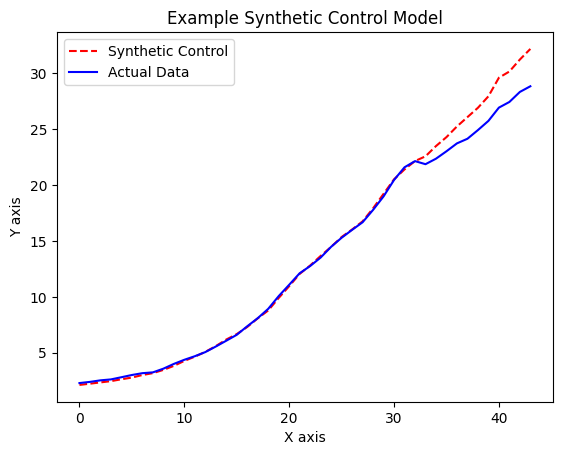

In [9]:
import numpy as np
import pandas as pd
from scipy.optimize import fmin_slsqp, minimize
from matplotlib import pyplot as plt

# -----------------------
import sys
sys.path.append('/content/drive/MyDrive/ColabNotebooks/SCMCourseWork/src/scmlib')

import scmsolver
from scmsolver import scm_solve
from scmsolver import basic_dataprep

X0, X1, Y0_pre, Y1_pre, Y0, Y1 = scmsolver.basic_dataprep(predictors_primary_df_T,
                             outcomes_primary_df_pivoted,
                             'West Germany',
                             predictors_primary_df_T.columns.drop('West Germany').tolist(),
                             list(range(1960, 1991)), list(range(1960, 2004)))
# synth_tables = synth_Y1, Y1, matrix_V, vector_W, predictors_table, outcomes_table

res = scmsolver.scm_solve(Y0.values, Y0_pre.values, Y1_pre.values, X0.values, X1.values) # returned: {V, W, Y_1_synth}

# synth_tables = synth_Y1, Y1, matrix_V, vector_W, predictors_table, outcomes_table
germany_table = [res['Y_1_synth'], Y1, res['V'], res['W']]

plot(germany_table)

# ДАЛЕЕ ГРАФИКИ

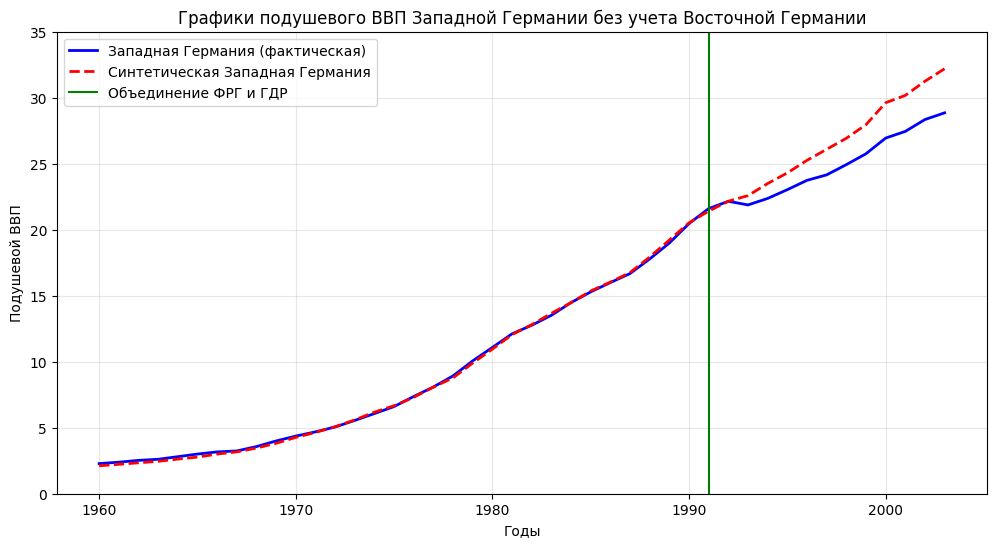

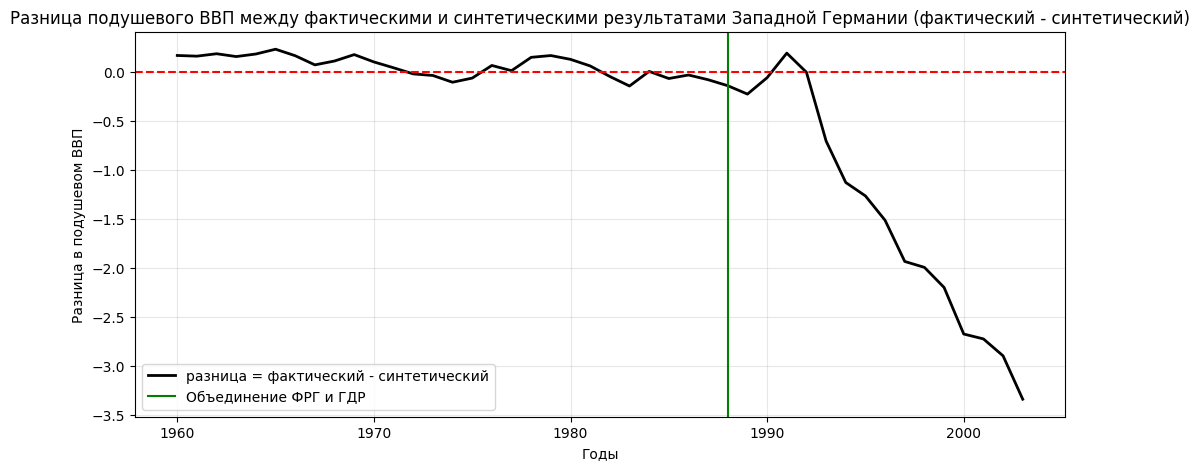

In [11]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
# germany_table = synth_Y1, Y1, matrix_V, vector_W
# 1. Расчет временного ряда на основе весов Абади
years = np.arange(1960, 2004)

Y1_synth = germany_table[0]
Y1 = germany_table[1]
# 2. Построение графика: Реальная vs Синтетическая Калифорния
plt.figure(figsize=(12, 6))
plt.plot(years, Y1, 'blue', label='Западная Германия (фактическая)', linewidth=2)
plt.plot(years, Y1_synth, 'r--', label='Синтетическая Западная Германия', linewidth=2)
plt.axvline(x=1991, color='green', linestyle='-', label='Объединение ФРГ и ГДР')
plt.title('Графики подушевого ВВП Западной Германии без учета Восточной Германии')
plt.xlabel('Годы')
plt.ylabel('Подушевой ВВП')
plt.ylim(0, 35)
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

# 3. График разности (Gap Plot)
gap = Y1 - Y1_synth

plt.figure(figsize=(12, 5))
plt.plot(years, gap, 'k-', linewidth=2, label='разница = фактический - синтетический')
plt.axhline(y=0, color='red', linestyle='--')
plt.axvline(x=1988, color='green', linestyle='-', label='Объединение ФРГ и ГДР')
plt.title('Разница подушевого ВВП между фактическими и синтетическими результатами Западной Германии (фактический - синтетический)')
plt.xlabel('Годы')
plt.ylabel('Разница в подушевом ВВП')
plt.grid(True, alpha=0.3)
plt.legend()
plt.show()